In [ ]:
import numpy as np
from utils.simulacoes import simular_genetico, simular_PID
from utils.geneticos_auxiliares import gerar_populacao_inicial, grafico_convergencia

In [2]:
SEED = 23

np.random.seed(SEED)

In [3]:
tf = 100.0
dt = 0.1

X0 = 0.3066
S0 = 0.2333

states = np.array([0.3066, 0.2333])

Xsp = 0.3066

D0 = 0.35


## Mudança no setpoint ($X_{sp} = 0.34$)

In [4]:
tamanho_povo = 100
N = 10
erro_individuo_lim = 1e-2
erro_desejado = 1e-4
Xsp_novo = 0.34

gen = gerar_populacao_inicial(tamanho_povo)

Kp_AG, Ti_AG, historico_erro = simular_genetico(iter_max=N, erro_desejado=erro_desejado,erro_individuo_lim=erro_individuo_lim, D0=D0, states=states, gen=gen, Xsp=Xsp_novo, dt=0.1, tf = 50)

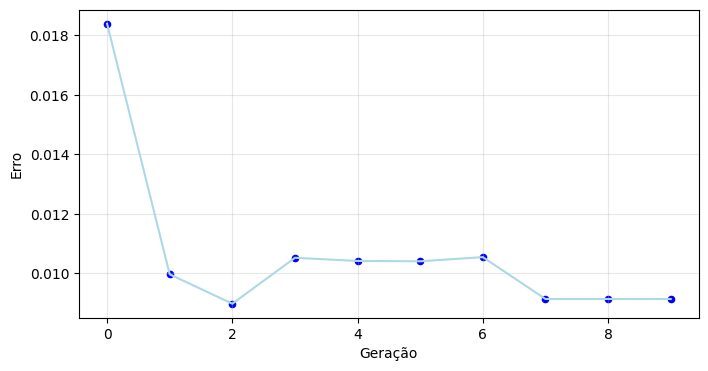

In [5]:
grafico_convergencia(historico_erro)

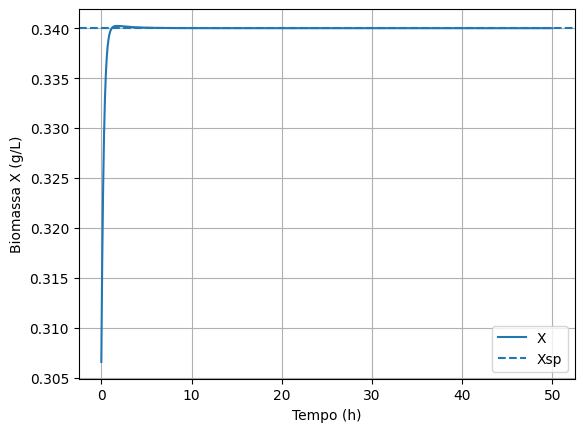

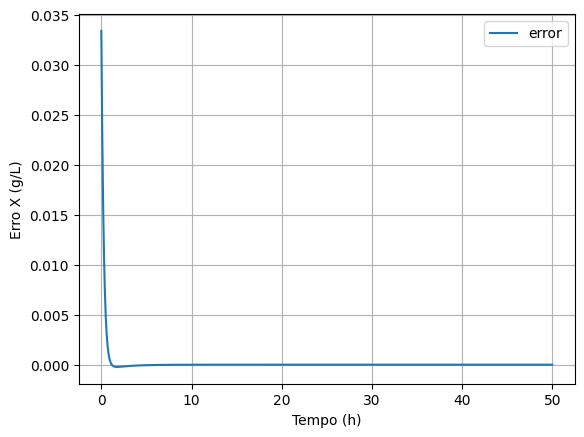

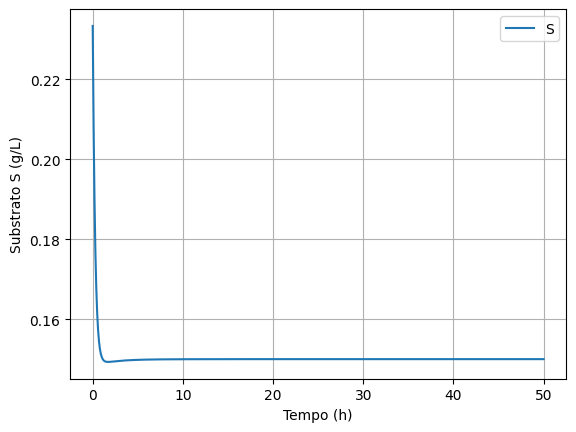

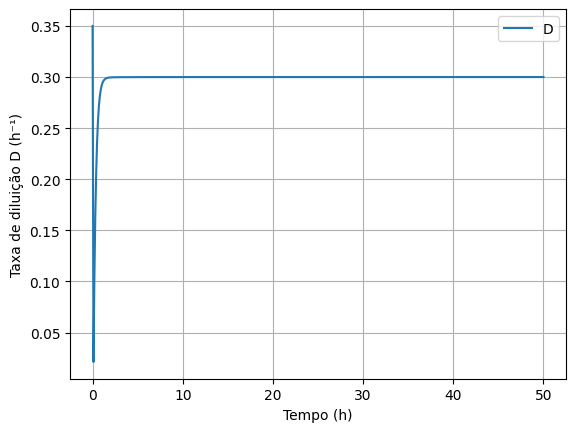

IAE: 0.0091422545508067, ISE: 0.00015601749173862505, Erro (Xsp - X): -7.89840415293952e-12
Kp: -9.32, Ti: 1.789


In [6]:
ttop, Xtop, Stop, Dtop, IAE_top, ISE_top, erro = simular_PID(Kc=Kp_AG, Ti=Ti_AG, Xsp=Xsp_novo, states=states, tempo_final=50, dt=0.1, show=True)
print(f"IAE: {IAE_top}, ISE: {ISE_top}, Erro (Xsp - X): {erro[-1]}")
print(f"Kp: {Kp_AG}, Ti: {Ti_AG}")

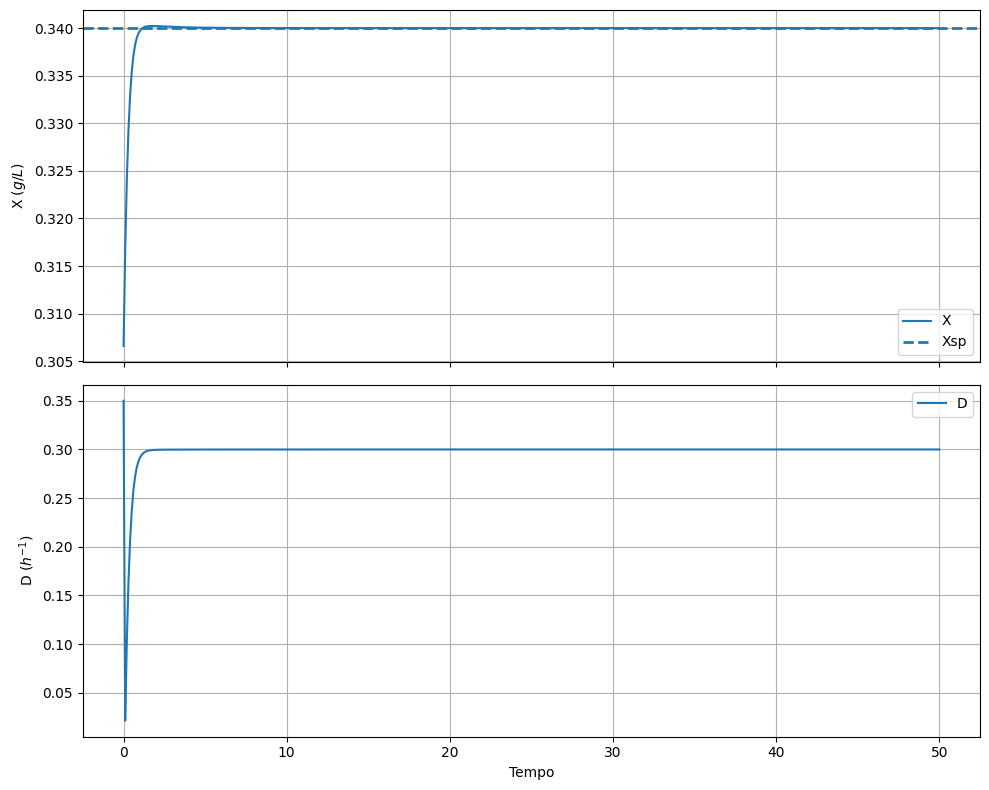

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Biomassa
ax1.plot(ttop, Xtop, label='X')
ax1.axhline(y=Xsp_novo, linestyle='--', linewidth=2, label='Xsp')
ax1.set_ylabel(r'X $(g/L)$')
ax1.grid(True)
ax1.legend()

# Controle
ax2.plot(ttop, Dtop, label='D')
ax2.set_xlabel('Tempo')
ax2.set_ylabel(r'D $(h^{-1}$)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

## Com pertubação (+20% em SF)

In [ ]:
Kp_AG_pert, Ti_AG_pert, historico_erro_pert = simular_genetico(iter_max=N, erro_desejado=erro_desejado,erro_individuo_lim=erro_individuo_lim, D0=D0, states=states, gen=gen, Xsp=Xsp, dt=0.1, tf = 50, pert=True, t_pert=20, Sf_pert = 1.2)

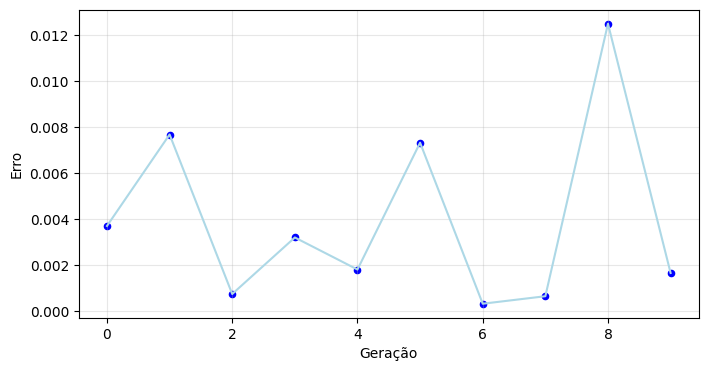

In [8]:
grafico_convergencia(historico_erro_pert)

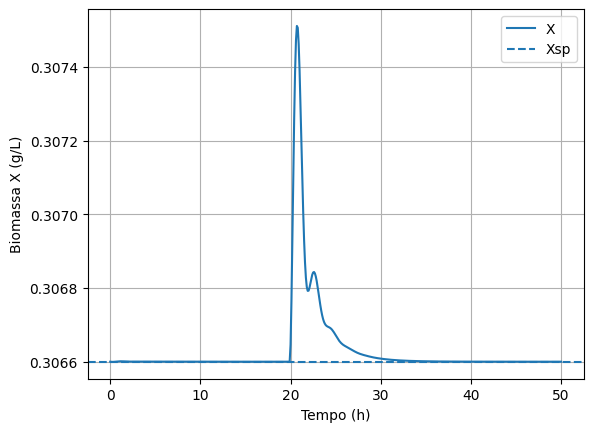

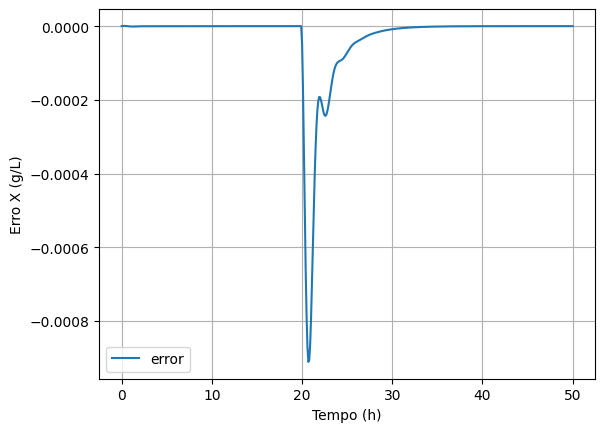

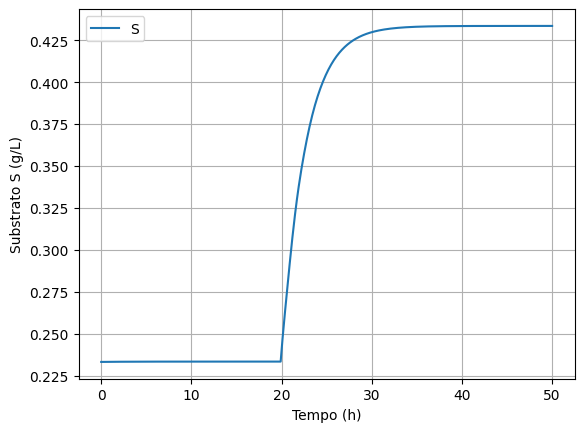

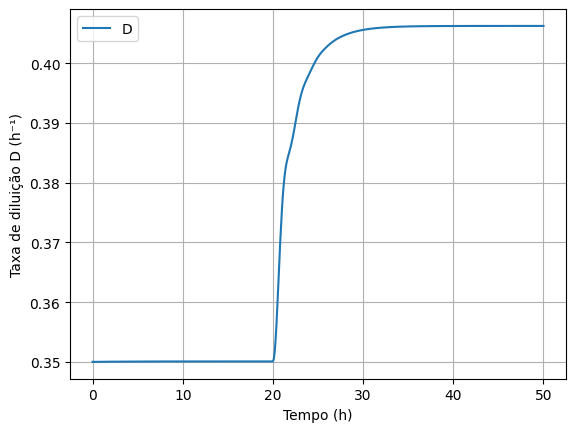

IAE: 0.001646036114450897, ISE: 7.641971947603557e-07, Erro (Xsp - X): -2.434877244272826e-09
Kp: -5.643, Ti: 0.165


In [9]:
ttop_pert, Xtop_pert, Stop_pert, Dtop_pert, IAE_top_pert, ISE_top_pert, erro_pert = simular_PID(Kc=Kp_AG_pert, Ti=Ti_AG_pert, Xsp=Xsp, D0=D0, states=states, tempo_final=50, dt=0.1, show=True, pert=True, t_pert=20, Sf_pert = 1.2)
print(f"IAE: {IAE_top_pert}, ISE: {ISE_top_pert}, Erro (Xsp - X): {erro_pert[-1]}")
print(f"Kp: {Kp_AG_pert}, Ti: {Ti_AG_pert}")

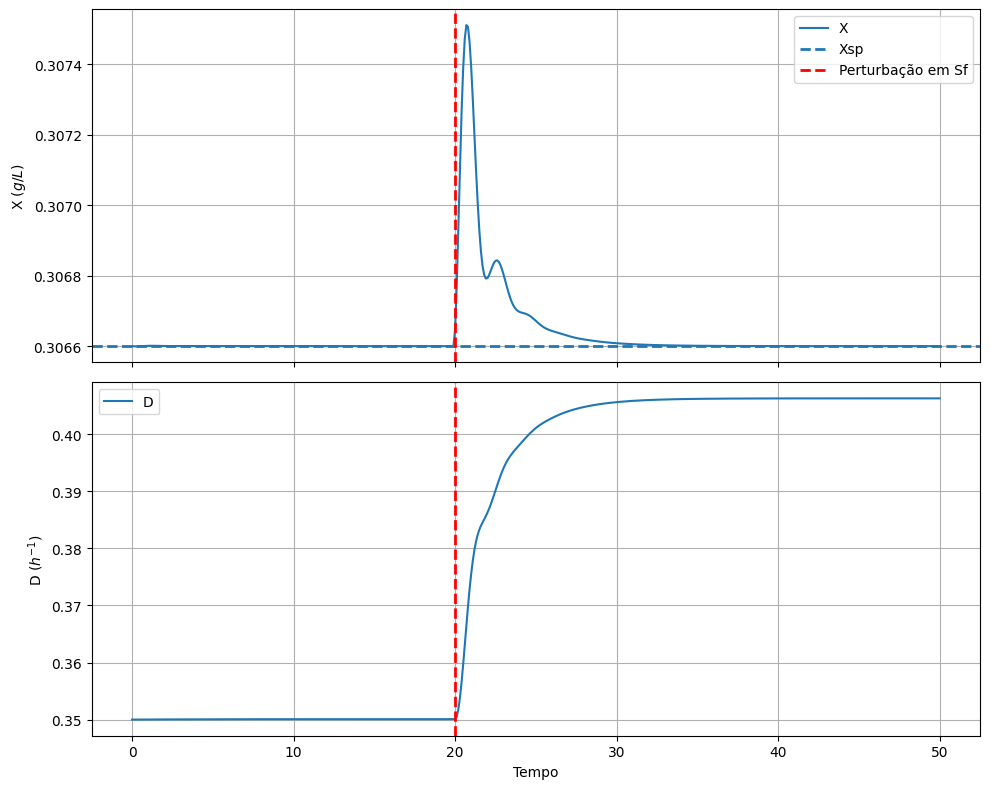

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico de X
ax1.plot(ttop_pert, Xtop_pert, label='X')
ax1.axhline(y=Xsp, linestyle='--', linewidth=2, label='Xsp')
ax1.axvline(x=20, linestyle='--', linewidth=2, label='Perturbação em Sf', color='red')
ax1.set_ylabel(r'X $(g/L)$')
ax1.grid(True)
ax1.legend()

# Gráfico de D
ax2.plot(ttop_pert, Dtop_pert, label='D')
ax2.axvline(x=20, linestyle='--', linewidth=2, color='red')
ax2.set_xlabel('Tempo')
ax2.set_ylabel(r'D $(h^{-1}$)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

## $X_0 = 0.28$, Pertubação em Sf

In [10]:
states_novo = np.array([0.28, 0.2333])
Kp_AG_pert_s, Ti_AG_pert_s, historico_erro_pert_s = simular_genetico(iter_max=N, erro_desejado=erro_desejado,erro_individuo_lim=erro_individuo_lim, D0=D0, states=states_novo, gen=gen, Xsp=Xsp, dt=0.1, tf = 50, pert=True, t_pert=20, Sf_pert = 1.2)

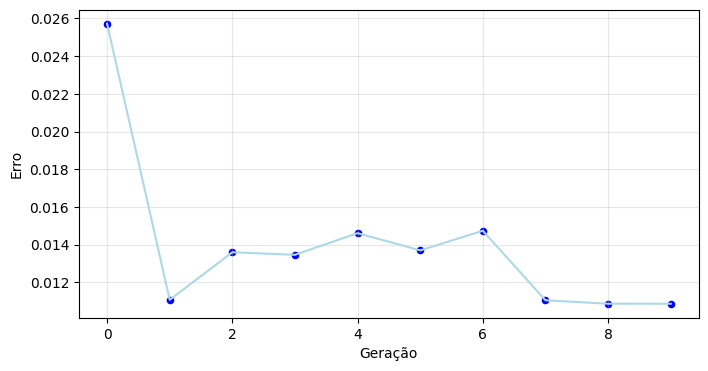

In [11]:
grafico_convergencia(historico_erro_pert_s)

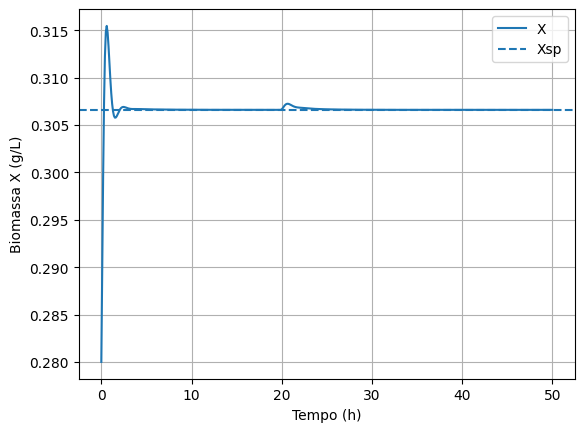

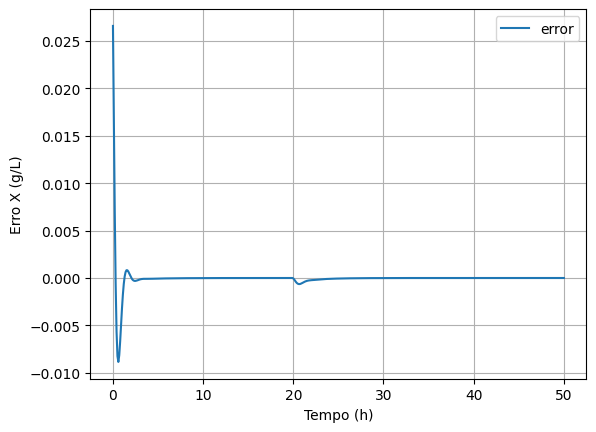

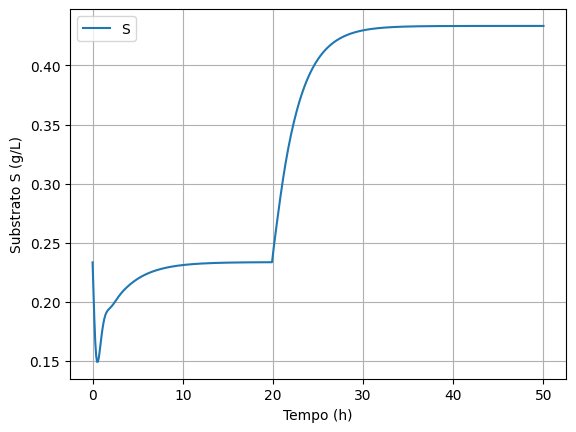

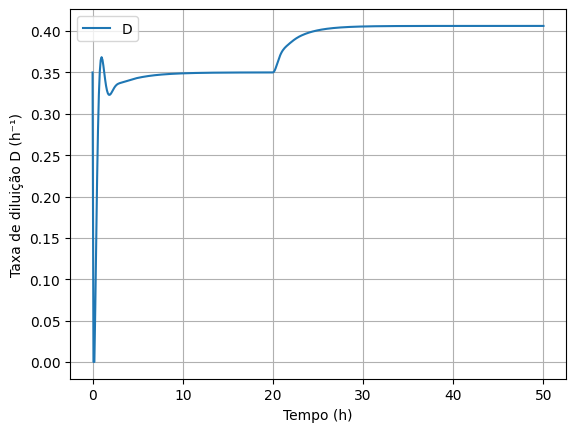

IAE: 0.010869624241007294, ISE: 0.00010213252265945054, Erro (Xsp - X): -2.0270040090863972e-09
Kp: -9.985, Ti: 0.235


In [17]:
ttop_pert_s, Xtop_pert_s, Stop_pert_s, Dtop_pert_s, IAE_top_pert_s, ISE_top_pert_s, erro_pert_s = simular_PID(Kc=Kp_AG_pert_s, Ti=Ti_AG_pert_s, Xsp=Xsp, D0=D0, states=states_novo, tempo_final=50, dt=0.1, show=True, pert=True, t_pert=20, Sf_pert = 1.2)
print(f"IAE: {IAE_top_pert_s}, ISE: {ISE_top_pert_s}, Erro (Xsp - X): {erro_pert_s[-1]}")
print(f"Kp: {Kp_AG_pert_s}, Ti: {Ti_AG_pert_s}")

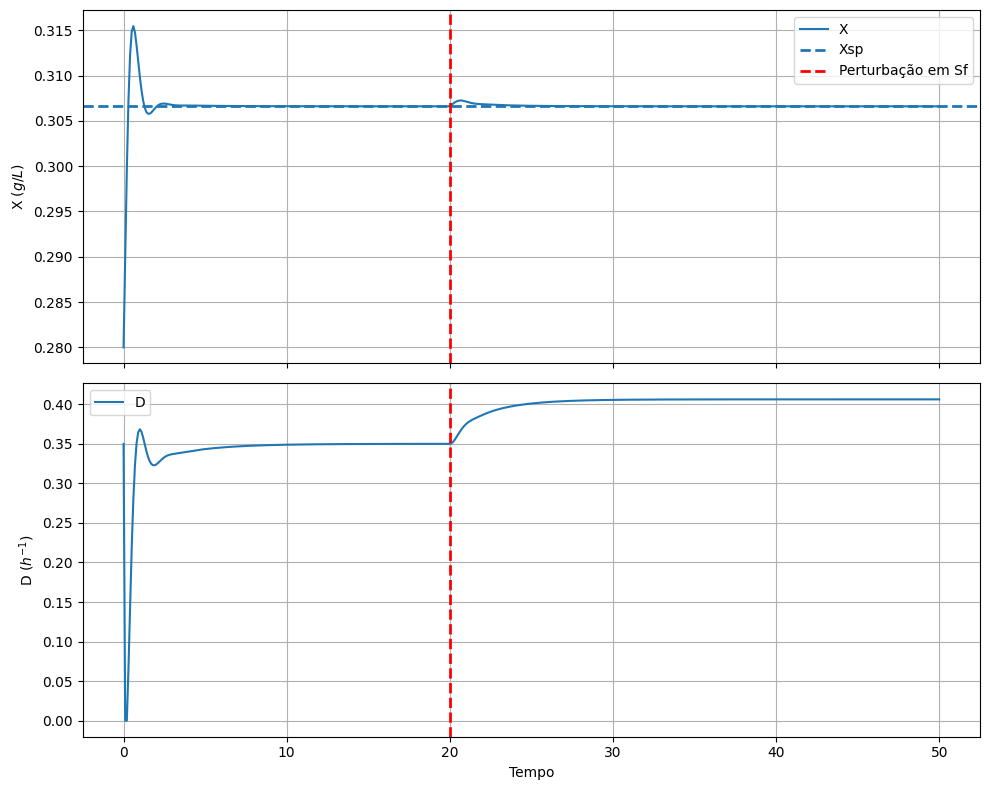

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico de X
ax1.plot(ttop_pert_s, Xtop_pert_s, label='X')
ax1.axhline(y=Xsp, linestyle='--', linewidth=2, label='Xsp')
ax1.axvline(x=20, linestyle='--', linewidth=2, label='Perturbação em Sf', color='red')
ax1.set_ylabel(r'X $(g/L)$')
ax1.grid(True)
ax1.legend()

# Gráfico de D
ax2.plot(ttop_pert_s, Dtop_pert_s, label='D')
ax2.axvline(x=20, linestyle='--', linewidth=2, color='red')
ax2.set_xlabel('Tempo')
ax2.set_ylabel(r'D $(h^{-1}$)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()